# Imports & Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings("ignore")

# TensorFlow / Keras
USE_TF = True
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print("TensorFlow loaded successfully.")
except Exception as e:
    USE_TF = False
    print("TensorFlow not available. Model training will be skipped.")
    print("Reason:", e)

np.random.seed(42)
if USE_TF:
    tf.random.set_seed(42)

TensorFlow loaded successfully.


# Load and preprocess MovieLens

In [13]:
print("[1] Loading MovieLens dataset...")

# Change these file names if needed
ratings = pd.read_csv("ratings.csv")   # or rating.csv
movies = pd.read_csv("movies.csv")     # or movie.csv

# Standardize column names
ratings.columns = [col.strip().lower() for col in ratings.columns]
movies.columns = [col.strip().lower() for col in movies.columns]

print("Ratings columns:", ratings.columns.tolist())
print("Movies columns :", movies.columns.tolist())

# Ensure expected names
# Expected after lowercasing: userid, movieid, rating, timestamp
if "userid" not in ratings.columns or "movieid" not in ratings.columns or "rating" not in ratings.columns:
    raise ValueError("ratings.csv must contain userid, movieid, rating columns.")

if "timestamp" not in ratings.columns:
    raise ValueError("ratings.csv must contain timestamp column.")

# Convert timestamp
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s", errors="coerce")

# Keep only needed columns
df = ratings[["userid", "movieid", "rating", "timestamp", "datetime"]].copy()

# Remove duplicates and missing
df = df.drop_duplicates().dropna().copy()

# Sort by time
df = df.sort_values("timestamp").reset_index(drop=True)

# Create user / item indices for embeddings
user_map = {u: i for i, u in enumerate(df["userid"].unique())}
item_map = {m: i for i, m in enumerate(df["movieid"].unique())}

df["user_idx"] = df["userid"].map(user_map).astype(int)
df["item_idx"] = df["movieid"].map(item_map).astype(int)

n_users = df["user_idx"].nunique()
n_items = df["item_idx"].nunique()

# Normalize rating from [1,5] -> [0,1]
df["rating_norm"] = (df["rating"] - 1.0) / 4.0

# Normalize timestamp from [min,max] -> [0,1]
ts_min = df["datetime"].min()
ts_max = df["datetime"].max()

df["timestamp_norm"] = (
    (df["datetime"] - ts_min).dt.total_seconds() /
    (ts_max - ts_min).total_seconds()
).astype(np.float32)

print(f"Users   : {n_users:,}")
print(f"Items   : {n_items:,}")
print(f"Ratings : {len(df):,}")
print(f"Date range: {ts_min.date()} to {ts_max.date()}")

display(df.head())

[1] Loading MovieLens dataset...
Ratings columns: ['userid', 'movieid', 'rating', 'timestamp']
Movies columns : ['movieid', 'title', 'genres']
Users   : 6,040
Items   : 3,706
Ratings : 1,000,209
Date range: 2000-04-25 to 2003-02-28


,userid,movieid,rating,timestamp,datetime,user_idx,item_idx,rating_norm,timestamp_norm
0,6040,858,4,956703932,2000-04-25 23:05:32,0,0,0.75,0.000000e+00
1,6040,593,5,956703954,2000-04-25 23:05:54,0,1,1.00,2.451235e-07
2,6040,2384,4,956703954,2000-04-25 23:05:54,0,2,0.75,2.451235e-07
3,6040,1961,4,956703977,2000-04-25 23:06:17,0,3,0.75,5.013891e-07
4,6040,2019,5,956703977,2000-04-25 23:06:17,0,4,1.00,5.013891e-07


# Inject synthetic noise

In [14]:
print("[2] Injecting synthetic noise for evaluation...")

df_clean = df.copy()
df_noisy = df.copy()

# -----------------------------
# A. Natural noise: Gaussian perturbation on ratings
# -----------------------------
GAUSSIAN_STD = 0.5

df_noisy["rating_corrupted"] = np.clip(
    df_noisy["rating"] + np.random.normal(0, GAUSSIAN_STD, len(df_noisy)),
    1.0, 5.0
)

df_noisy["rating_corrupted_norm"] = (
    (df_noisy["rating_corrupted"] - 1.0) / 4.0
).astype(np.float32)

# -----------------------------
# B. Malicious noise: synthetic shilling profiles
# -----------------------------
ATTACK_RATIO = 0.02   # 2% fake users relative to real users
n_fake = max(10, int(n_users * ATTACK_RATIO))

# Choose target items from popular items
popular_items = df.groupby("movieid").size().sort_values(ascending=False).head(20).index.tolist()
target_items = popular_items[:5]

fake_rows = []
start_fake_user = n_users

for fake_u in range(start_fake_user, start_fake_user + n_fake):
    # filler items
    filler_items = np.random.choice(df["movieid"].unique(), size=20, replace=False)

    # target push attack
    for item in target_items:
        fake_rows.append({
            "userid": f"fake_{fake_u}",
            "movieid": item,
            "rating": 5.0,
            "timestamp": np.nan,
            "datetime": pd.NaT,
            "user_idx": fake_u,
            "item_idx": item_map.get(item, 0),
            "rating_norm": 1.0,
            "rating_corrupted": 5.0,
            "rating_corrupted_norm": 1.0,
            "timestamp_norm": np.random.uniform(0.8, 1.0),
            "is_attack": 1
        })

    # filler ratings
    for item in filler_items:
        fake_rows.append({
            "userid": f"fake_{fake_u}",
            "movieid": item,
            "rating": np.random.choice([1.0, 2.0, 4.0, 5.0]),
            "timestamp": np.nan,
            "datetime": pd.NaT,
            "user_idx": fake_u,
            "item_idx": item_map.get(item, 0),
            "rating_norm": np.random.uniform(0.0, 1.0),
            "rating_corrupted": np.random.choice([1.0, 2.0, 4.0, 5.0]),
            "rating_corrupted_norm": np.random.uniform(0.0, 1.0),
            "timestamp_norm": np.random.uniform(0.8, 1.0),
            "is_attack": 1
        })

df_attacks = pd.DataFrame(fake_rows)

df_noisy["is_attack"] = 0
df_combined = pd.concat([df_noisy, df_attacks], ignore_index=True, sort=False)

n_users_ext = n_users + n_fake

print(f"Clean dataset rows    : {len(df_clean):,}")
print(f"Gaussian noise std    : {GAUSSIAN_STD}")
print(f"Fake users injected   : {n_fake:,}")
print(f"Target items attacked : {target_items}")
print(f"Combined training rows: {len(df_combined):,}")
print(f"Attack proportion     : {n_fake/len(df_combined)*100:.2f}%")

[2] Injecting synthetic noise for evaluation...
Clean dataset rows    : 1,000,209
Gaussian noise std    : 0.5
Fake users injected   : 120
Target items attacked : [2858, 260, 1196, 1210, 480]
Combined training rows: 1,003,209
Attack proportion     : 0.01%


# Temporal feature engineering

[3] Temporal Feature Engineering...
Temporal weight range: 0.135 – 1.000


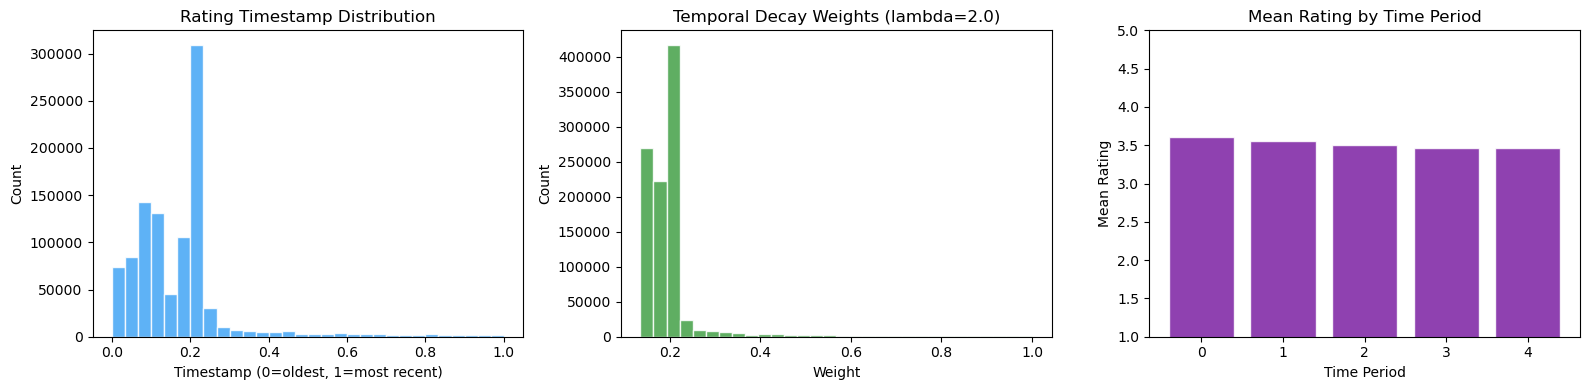

Saved: fig_movielens_temporal_features.png


In [15]:
print("[3] Temporal Feature Engineering...")

DECAY_LAMBDA = 2.0

df_combined["temporal_weight"] = np.exp(
    -DECAY_LAMBDA * (1 - df_combined["timestamp_norm"].fillna(0.5))
).astype(np.float32)

df_clean["temporal_weight"] = np.exp(
    -DECAY_LAMBDA * (1 - df_clean["timestamp_norm"])
).astype(np.float32)

df_combined["temporal_bucket"] = pd.cut(
    df_combined["timestamp_norm"].fillna(0.5),
    bins=5, labels=[0, 1, 2, 3, 4]
).astype(float)

df_clean["temporal_bucket"] = pd.cut(
    df_clean["timestamp_norm"],
    bins=5, labels=[0, 1, 2, 3, 4]
).astype(float)

print(f"Temporal weight range: {df_combined['temporal_weight'].min():.3f} – {df_combined['temporal_weight'].max():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_clean["timestamp_norm"], bins=30, color="#42a5f5", edgecolor="white", alpha=0.85)
axes[0].set_title("Rating Timestamp Distribution")
axes[0].set_xlabel("Timestamp (0=oldest, 1=most recent)")
axes[0].set_ylabel("Count")

axes[1].hist(df_clean["temporal_weight"], bins=30, color="#43a047", edgecolor="white", alpha=0.85)
axes[1].set_title(f"Temporal Decay Weights (lambda={DECAY_LAMBDA})")
axes[1].set_xlabel("Weight")
axes[1].set_ylabel("Count")

bucket_means = df_clean.groupby("temporal_bucket")["rating"].mean()
axes[2].bar(bucket_means.index.astype(int), bucket_means.values,
            color="#7b1fa2", edgecolor="white", alpha=0.85)
axes[2].set_title("Mean Rating by Time Period")
axes[2].set_xlabel("Time Period")
axes[2].set_ylabel("Mean Rating")
axes[2].set_ylim(1, 5)

plt.tight_layout()
plt.savefig("fig_movielens_temporal_features.png", bbox_inches="tight")
plt.show()
print("Saved: fig_movielens_temporal_features.png")

# Build RADAE model

In [16]:
print("[4] Building RADAE Model Architecture...")

EMBED_DIM = 32
LATENT_DIM = 64
CONV_FILTERS = 64
CONV_KERNEL = 3
N_HEADS = 4
KEY_DIM = 16
DROPOUT = 0.2
LEARNING_RATE = 0.001

if USE_TF:
    def build_radae(n_users_in, n_items_in,
                    embed_dim=EMBED_DIM, latent_dim=LATENT_DIM,
                    conv_filters=CONV_FILTERS, conv_kernel=CONV_KERNEL,
                    n_heads=N_HEADS, key_dim=KEY_DIM, dropout=DROPOUT):

        user_input = layers.Input(shape=(1,), name="user_input", dtype="int32")
        item_input = layers.Input(shape=(1,), name="item_input", dtype="int32")
        ts_input = layers.Input(shape=(1,), name="ts_input", dtype="float32")
        rating_input = layers.Input(shape=(1,), name="rating_input", dtype="float32")

        user_emb = layers.Embedding(n_users_in + 1, embed_dim, name="user_embedding")(user_input)
        user_emb = layers.Flatten()(user_emb)

        item_emb = layers.Embedding(n_items_in + 1, embed_dim, name="item_embedding")(item_input)
        item_emb = layers.Flatten()(item_emb)

        ts_enc = layers.Dense(embed_dim, activation="relu", name="temporal_encoder")(ts_input)
        rating_enc = layers.Dense(embed_dim, activation="relu", name="rating_encoder")(rating_input)

        concat = layers.Concatenate(name="concat_embeddings")([user_emb, item_emb, ts_enc, rating_enc])

        x = layers.Reshape((4, embed_dim))(concat)

        # Conv1D encoder
        x = layers.Conv1D(filters=conv_filters, kernel_size=conv_kernel,
                          padding="same", activation="relu")(x)

        # Multi-head attention
        attn_out = layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=key_dim, dropout=dropout
        )(x, x)

        # Residual connection
        x = layers.Add()([x, attn_out])
        x = layers.LayerNormalization()(x)

        x = layers.Flatten()(x)
        x = layers.Dense(latent_dim, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(latent_dim // 2, activation="relu")(x)

        output = layers.Dense(1, activation="sigmoid", name="denoised_rating")(x)

        model = Model(
            inputs=[user_input, item_input, ts_input, rating_input],
            outputs=output,
            name="RADAE_MovieLens"
        )

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss=tf.keras.losses.Huber(delta=1.0),
            metrics=["mae"]
        )

        return model

    radae_model = build_radae(n_users_ext, n_items)
    radae_model.summary()

[4] Building RADAE Model Architecture...


Model: "RADAE_MovieLens"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ item_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_embedding (Embedding)    │ (None, 1, 32)             │         197,152 │ user_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ item_embedding (Embedding)    │ (None, 1, 32)             │         118,624 │ item_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ts_input (InputLayer)         │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rating_input (InputLayer)     │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 32)                │               0 │ user_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 32)                │               0 │ item_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ temporal_encoder (Dense)      │ (None, 32)                │              64 │ ts_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rating_encoder (Dense)        │ (None, 32)                │              64 │ rating_input[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concat_embeddings             │ (None, 128)               │               0 │ flatten[0][0],             │
│ (Concatenate)                 │                           │                 │ flatten_1[0][0],           │
│                               │                           │                 │ temporal_encoder[0][0],    │
│                               │                           │                 │ rating_encoder[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 4, 32)             │               0 │ concat_embeddings[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 4, 64)             │           6,208 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 4, 64)             │          16,640 │ conv1d[0][0], conv1d[0][0] │
│ (MultiHeadAttention)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 4, 64)             │               0 │ conv1d[0][0],              │
│                               │                           │               

 Total params: 357,441 (1.36 MB)

 Trainable params: 357,441 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# Train RADAE

[5] Training RADAE...
Train interactions: 803,167
Test interactions : 200,042
Epoch 1/50
6275/6275 ━━━━━━━━━━━━━━━━━━━━ 136s 20ms/step - loss: 0.0062 - mae: 0.0845 - val_loss: 0.0020 - val_mae: 0.0495 - learning_rate: 0.0010
Epoch 2/50
6275/6275 ━━━━━━━━━━━━━━━━━━━━ 111s 18ms/step - loss: 0.0057 - mae: 0.0786 - val_loss: 0.0019 - val_mae: 0.0474 - learning_rate: 0.0010
Epoch 3/50
6275/6275 ━━━━━━━━━━━━━━━━━━━━ 106s 17ms/step - loss: 0.0055 - mae: 0.0757 - val_loss: 0.0018 - val_mae: 0.0440 - learning_rate: 0.0010
Epoch 4/50
6275/6275 ━━━━━━━━━━━━━━━━━━━━ 141s 17ms/step - loss: 0.0052 - mae: 0.0729 - val_loss: 0.0018 - val_mae: 0.0419 - learning_rate: 0.0010
Epoch 5/50
6275/6275 ━━━━━━━━━━━━━━━━━━━━ 107s 17ms/step - loss: 0.0050 - mae: 0.0703 - val_loss: 0.0017 - val_mae: 0.0397 - learning_rate: 0.0010
Epoch 6/50
6275/6275 ━━━━━━━━━━━━━━━━━━━━ 121s 19ms/step - loss: 0.0048 - mae: 0.0677 - val_loss: 0.0016 - val_mae: 0.0383 - learning_rate: 0.0010
Epoch 7/50
6275/6275 ━━━━━━━━━━━━━━━━━━━

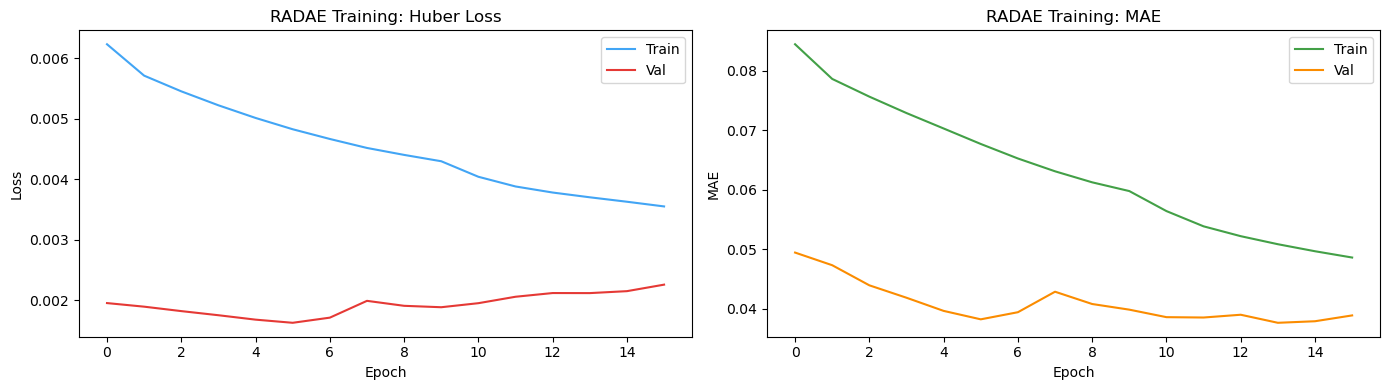

Saved: fig_movielens_training_curves.png


In [17]:
print("[5] Training RADAE...")

idx_all = np.arange(len(df_clean))
idx_train, idx_test = train_test_split(idx_all, test_size=0.20, random_state=42)

train_df = df_noisy.iloc[idx_train].copy()
test_df = df_clean.iloc[idx_test].copy()

# Add attacks only to training
train_with_attacks = pd.concat([train_df, df_attacks], ignore_index=True, sort=False)

train_with_attacks["rating_corrupted_norm"] = train_with_attacks["rating_corrupted_norm"].fillna(train_with_attacks["rating_norm"])
train_with_attacks["timestamp_norm"] = train_with_attacks["timestamp_norm"].fillna(0.5)
train_with_attacks["user_idx"] = train_with_attacks["user_idx"].astype(int)
train_with_attacks["item_idx"] = train_with_attacks["item_idx"].astype(int)

print(f"Train interactions: {len(train_with_attacks):,}")
print(f"Test interactions : {len(test_df):,}")

if USE_TF:
    X_user_tr = train_with_attacks["user_idx"].values.astype(np.int32)
    X_item_tr = train_with_attacks["item_idx"].values.astype(np.int32)
    X_ts_tr = train_with_attacks["timestamp_norm"].values.astype(np.float32)
    X_rating_tr = train_with_attacks["rating_corrupted_norm"].values.astype(np.float32)
    Y_tr = train_with_attacks["rating_norm"].values.astype(np.float32)

    X_user_te = test_df["user_idx"].values.astype(np.int32)
    X_item_te = test_df["item_idx"].values.astype(np.int32)
    X_ts_te = test_df["timestamp_norm"].values.astype(np.float32)
    X_rating_te = test_df["rating_norm"].values.astype(np.float32)
    Y_te = test_df["rating_norm"].values.astype(np.float32)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1, min_lr=1e-5)
    ]

    EPOCHS = 50
    BATCH_SIZE = 128

    history = radae_model.fit(
        [X_user_tr, X_item_tr, X_ts_tr, X_rating_tr], Y_tr,
        validation_data=([X_user_te, X_item_te, X_ts_te, X_rating_te], Y_te),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["loss"], label="Train", color="#42a5f5")
    axes[0].plot(history.history["val_loss"], label="Val", color="#e53935")
    axes[0].set_title("RADAE Training: Huber Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="Train", color="#43a047")
    axes[1].plot(history.history["val_mae"], label="Val", color="#fb8c00")
    axes[1].set_title("RADAE Training: MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("fig_movielens_training_curves.png", bbox_inches="tight")
    plt.show()
    print("Saved: fig_movielens_training_curves.png")

# Evaluate RADAE

In [20]:
print(test_df.columns.tolist())

['userid', 'movieid', 'rating', 'timestamp', 'datetime', 'user_idx', 'item_idx', 'rating_norm', 'timestamp_norm', 'temporal_weight', 'temporal_bucket']


In [21]:
print("[6] Evaluating RADAE...")

def scale_back(norm_rating):
    return norm_rating * 4.0 + 1.0

if USE_TF:
    # Clean test input
    X_user_te = test_df["user_idx"].values.astype(np.int32)
    X_item_te = test_df["item_idx"].values.astype(np.int32)
    X_ts_te = test_df["timestamp_norm"].values.astype(np.float32)
    X_rating_te = test_df["rating_norm"].values.astype(np.float32)
    Y_te = test_df["rating_norm"].values.astype(np.float32)

    # Predict using clean ratings
    radae_preds = radae_model.predict(
        [X_user_te, X_item_te, X_ts_te, X_rating_te],
        verbose=0
    ).flatten()

    # Create corrupted version of test ratings manually
    corrupted_test_ratings = np.clip(
        test_df["rating"].values + np.random.normal(0, GAUSSIAN_STD, len(test_df)),
        1.0, 5.0
    )

    corrupted_test_input = ((corrupted_test_ratings - 1.0) / 4.0).astype(np.float32)

    # Predict using corrupted input
    corrupted_preds = radae_model.predict(
        [X_user_te, X_item_te, X_ts_te, corrupted_test_input],
        verbose=0
    ).flatten()

    # Convert back to star scale
    radae_preds_stars = scale_back(radae_preds)
    actual_stars = scale_back(Y_te)
    corrupted_stars = scale_back(corrupted_preds)

    # Metrics
    rmse_radae = float(np.sqrt(mean_squared_error(actual_stars, radae_preds_stars)))
    mae_radae = float(mean_absolute_error(actual_stars, radae_preds_stars))
    rmse_corr = float(np.sqrt(mean_squared_error(actual_stars, corrupted_stars)))
    mae_corr = float(mean_absolute_error(actual_stars, corrupted_stars))

    print(f"RADAE (clean input) RMSE: {rmse_radae:.4f}  MAE: {mae_radae:.4f}")
    print(f"RADAE (noisy input) RMSE: {rmse_corr:.4f}  MAE: {mae_corr:.4f}")
    print(f"Denoising improvement RMSE: {(rmse_corr - rmse_radae) / rmse_corr * 100:+.2f}%")

[6] Evaluating RADAE...
RADAE (clean input) RMSE: 0.2283  MAE: 0.1531
RADAE (noisy input) RMSE: 0.4511  MAE: 0.3190
Denoising improvement RMSE: +49.40%


# Ranking Metrics

In [22]:
print("[6b] Ranking Metrics...")

if USE_TF:
    THRESHOLD = 4.0
    K_VALS = [3, 5]

    user_pred_dict = {}
    user_actual_dict = {}

    for u, i, p, a in zip(X_user_te, X_item_te, radae_preds_stars, actual_stars):
        u = int(u)
        i = int(i)
        user_pred_dict.setdefault(u, {})[i] = float(p)
        user_actual_dict.setdefault(u, {})[i] = float(a)

    ranking_results = {}

    for k in K_VALS:
        precisions, recalls, ndcgs = [], [], []
        discounts = 1.0 / np.log2(np.arange(2, k + 2))

        for u in user_pred_dict:
            items_pred = user_pred_dict[u]
            items_actual = user_actual_dict[u]

            relevant_set = {i for i, r in items_actual.items() if r >= THRESHOLD}
            if not relevant_set:
                continue

            top_k = sorted(items_pred, key=items_pred.get, reverse=True)[:k]
            hits = [1 if i in relevant_set else 0 for i in top_k]

            precision = np.mean(hits)
            recall = np.sum(hits) / len(relevant_set)

            dcg = np.sum(np.array(hits) * discounts[:len(hits)])
            ideal_hits = [1] * min(len(relevant_set), k)
            idcg = np.sum(np.array(ideal_hits) * discounts[:len(ideal_hits)])
            ndcg = dcg / idcg if idcg > 0 else 0.0

            precisions.append(precision)
            recalls.append(recall)
            ndcgs.append(ndcg)

        ranking_results[k] = {
            "precision": float(np.mean(precisions)) if precisions else 0.0,
            "recall": float(np.mean(recalls)) if recalls else 0.0,
            "ndcg": float(np.mean(ndcgs)) if ndcgs else 0.0
        }

    print(f'{"K":>4} {"P@K":>8} {"R@K":>8} {"NDCG@K":>10}')
    for k in K_VALS:
        r = ranking_results[k]
        print(f'{k:>4} {r["precision"]:>8.4f} {r["recall"]:>8.4f} {r["ndcg"]:>10.4f}')

[6b] Ranking Metrics...
   K      P@K      R@K     NDCG@K
   3   0.9722   0.3711     1.0000
   5   0.9324   0.5141     1.0000


# Compare with no-defence baseline

[7] Comparison: RADAE vs No-Defence Baseline...
Method                           RMSE      MAE
----------------------------------------------
No Defence (SVD baseline)      1.7908   1.4057
RADAE (MovieLens)              0.2283   0.1531

RMSE improvement: +87.25%
MAE improvement : +89.11%


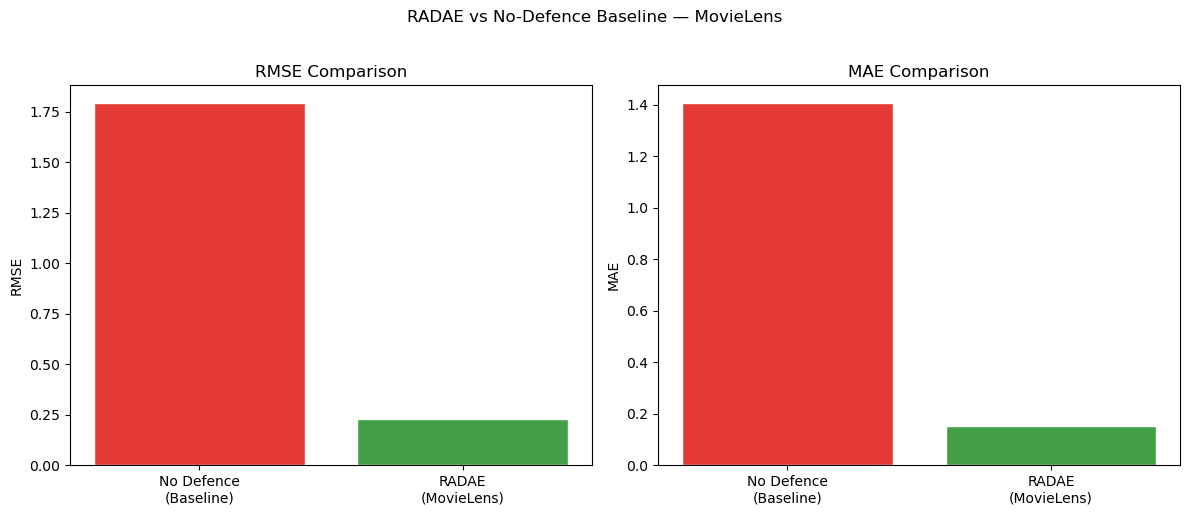

Saved: fig_movielens_comparison.png


In [23]:
print("[7] Comparison: RADAE vs No-Defence Baseline...")

R_noisy_mat = np.zeros((n_users_ext, n_items), dtype=np.float32)

for row in train_with_attacks.itertuples(index=False):
    u = int(getattr(row, "user_idx", 0))
    i = int(getattr(row, "item_idx", 0))
    if u < n_users_ext and i < n_items:
        R_noisy_mat[u, i] = float(getattr(row, "rating_corrupted_norm", row.rating_norm))

# Hold out test pairs
for row in test_df.itertuples(index=False):
    u = int(getattr(row, "user_idx", 0))
    i = int(getattr(row, "item_idx", 0))
    if u < n_users_ext and i < n_items:
        R_noisy_mat[u, i] = 0.0

n_fac = min(20, n_items - 1)
svd_nd = TruncatedSVD(n_components=n_fac, random_state=42)
U_nd = svd_nd.fit_transform(R_noisy_mat)
R_pred_nd = np.clip(U_nd @ np.diag(svd_nd.singular_values_) @ svd_nd.components_, 0, 1)

nd_preds_stars = []
test_actual_stars = []

for row in test_df.itertuples(index=False):
    u = int(getattr(row, "user_idx", 0))
    i = int(getattr(row, "item_idx", 0))
    if u < n_users_ext and i < n_items:
        nd_preds_stars.append(scale_back(float(R_pred_nd[u, i])))
        test_actual_stars.append(float(row.rating))

rmse_nd = float(np.sqrt(mean_squared_error(test_actual_stars, nd_preds_stars)))
mae_nd = float(mean_absolute_error(test_actual_stars, nd_preds_stars))

print(f'{"Method":<28} {"RMSE":>8} {"MAE":>8}')
print("-" * 46)
print(f'{"No Defence (SVD baseline)":<28} {rmse_nd:>8.4f} {mae_nd:>8.4f}')
if USE_TF:
    print(f'{"RADAE (MovieLens)":<28} {rmse_radae:>8.4f} {mae_radae:>8.4f}')

if USE_TF:
    rmse_imp = (rmse_nd - rmse_radae) / rmse_nd * 100
    mae_imp = (mae_nd - mae_radae) / mae_nd * 100

    print(f"\nRMSE improvement: {rmse_imp:+.2f}%")
    print(f"MAE improvement : {mae_imp:+.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    methods = ["No Defence\n(Baseline)", "RADAE\n(MovieLens)"]
    colors = ["#e53935", "#43a047"]

    axes[0].bar(methods, [rmse_nd, rmse_radae], color=colors, edgecolor="white")
    axes[0].set_title("RMSE Comparison")
    axes[0].set_ylabel("RMSE")

    axes[1].bar(methods, [mae_nd, mae_radae], color=colors, edgecolor="white")
    axes[1].set_title("MAE Comparison")
    axes[1].set_ylabel("MAE")

    plt.suptitle("RADAE vs No-Defence Baseline — MovieLens", y=1.02)
    plt.tight_layout()
    plt.savefig("fig_movielens_comparison.png", bbox_inches="tight")
    plt.show()
    print("Saved: fig_movielens_comparison.png")

# Noise resilience analysis

[8] Noise Resilience Analysis...
Noise std 0.0: RMSE=0.2283 MAE=0.1531
Noise std 0.1: RMSE=0.2469 MAE=0.1664
Noise std 0.3: RMSE=0.3360 MAE=0.2299
Noise std 0.5: RMSE=0.4503 MAE=0.3179
Noise std 0.8: RMSE=0.6194 MAE=0.4537
Noise std 1.0: RMSE=0.7289 MAE=0.5400


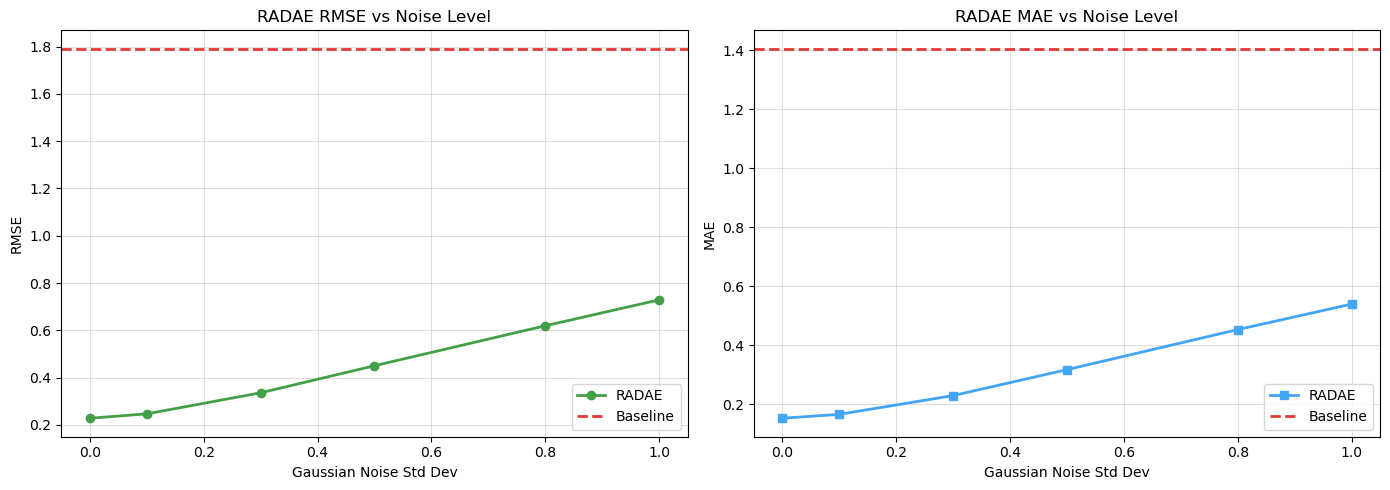

Saved: fig_movielens_resilience.png


In [24]:
print("[8] Noise Resilience Analysis...")

NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
resilience_rows = []

if USE_TF:
    for noise_std in NOISE_LEVELS:
        corrupted_ratings = np.clip(
            test_df["rating"].values + np.random.normal(0, noise_std, len(test_df)),
            1, 5
        )
        corrupted_norm = (corrupted_ratings - 1.0) / 4.0

        preds = radae_model.predict(
            [X_user_te, X_item_te, X_ts_te, corrupted_norm.astype(np.float32)],
            verbose=0
        ).flatten()

        preds_stars = scale_back(preds)
        actual_stars = test_df["rating"].values

        rmse = float(np.sqrt(mean_squared_error(actual_stars, preds_stars)))
        mae = float(mean_absolute_error(actual_stars, preds_stars))

        resilience_rows.append({
            "noise_std": noise_std,
            "RADAE_RMSE": round(rmse, 4),
            "RADAE_MAE": round(mae, 4)
        })

        print(f"Noise std {noise_std:.1f}: RMSE={rmse:.4f} MAE={mae:.4f}")

    resil_df = pd.DataFrame(resilience_rows)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(resil_df["noise_std"], resil_df["RADAE_RMSE"],
                 marker="o", color="#43a047", linewidth=2, label="RADAE")
    axes[0].axhline(rmse_nd, color="#e53935", linestyle="--", linewidth=2, label="Baseline")
    axes[0].set_title("RADAE RMSE vs Noise Level")
    axes[0].set_xlabel("Gaussian Noise Std Dev")
    axes[0].set_ylabel("RMSE")
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    axes[1].plot(resil_df["noise_std"], resil_df["RADAE_MAE"],
                 marker="s", color="#42a5f5", linewidth=2, label="RADAE")
    axes[1].axhline(mae_nd, color="#e53935", linestyle="--", linewidth=2, label="Baseline")
    axes[1].set_title("RADAE MAE vs Noise Level")
    axes[1].set_xlabel("Gaussian Noise Std Dev")
    axes[1].set_ylabel("MAE")
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig("fig_movielens_resilience.png", bbox_inches="tight")
    plt.show()
    print("Saved: fig_movielens_resilience.png")

# Final Result Summary

In [25]:
print("[9] MOVIELENS RADAE — FINAL RESULTS SUMMARY")
print("=" * 65)
print("Dataset: MovieLens")
print(f"Users    : {n_users}")
print(f"Items    : {n_items}")
print(f"Ratings  : {len(df_clean):,}")
print(f"Noise injected: Gaussian (std={GAUSSIAN_STD}) + Shilling ({n_fake} fake users)")
print()
print("Architecture: RADAE")
print(f"Embedding dim  : {EMBED_DIM}")
print(f"Latent dim     : {LATENT_DIM}")
print(f"Conv1D filters : {CONV_FILTERS}")
print(f"Attention heads: {N_HEADS}")
print()
print("EVALUATION RESULTS")
print(f'{"Method":<28} {"RMSE":>8} {"MAE":>8}')
print("-" * 46)
print(f'{"No Defence (SVD baseline)":<28} {rmse_nd:>8.4f} {mae_nd:>8.4f}')
if USE_TF:
    print(f'{"RADAE (MovieLens)":<28} {rmse_radae:>8.4f} {mae_radae:>8.4f}')
    print("-" * 46)
    print(f"RMSE improvement: {rmse_imp:+.2f}%")
    print(f"MAE improvement : {mae_imp:+.2f}%")

if USE_TF:
    print()
    print("TEMPORAL ANALYSIS")
    print(f"Date range: {ts_min.date()} to {ts_max.date()}")
    print(f"Temporal decay lambda: {DECAY_LAMBDA}")
    print(f"Weight range: {df_clean['temporal_weight'].min():.3f} – {df_clean['temporal_weight'].max():.3f}")

print("=" * 65)
print("[DONE] MovieLens RADAE workflow complete.")

[9] MOVIELENS RADAE — FINAL RESULTS SUMMARY
Dataset: MovieLens
Users    : 6040
Items    : 3706
Ratings  : 1,000,209
Noise injected: Gaussian (std=0.5) + Shilling (120 fake users)

Architecture: RADAE
Embedding dim  : 32
Latent dim     : 64
Conv1D filters : 64
Attention heads: 4

EVALUATION RESULTS
Method                           RMSE      MAE
----------------------------------------------
No Defence (SVD baseline)      1.7908   1.4057
RADAE (MovieLens)              0.2283   0.1531
----------------------------------------------
RMSE improvement: +87.25%
MAE improvement : +89.11%

TEMPORAL ANALYSIS
Date range: 2000-04-25 to 2003-02-28
Temporal decay lambda: 2.0
Weight range: 0.135 – 1.000
[DONE] MovieLens RADAE workflow complete.
